# Ephesos capability tour

This notebook uses deterministic simulated systems to exercise the installed Ephesos public API. It writes generated figures directly to `visuals/`.

## 1. Install and Import Ephesos

Install the repository once with `python -m pip install -e .` from the Ephesos root. The next cell imports the installed package, reports its version, and fixes the NumPy random seed for reproducibility.

In [ ]:
from importlib.metadata import PackageNotFoundError, version
import inspect
from pathlib import Path
import time
import tomllib
import tracemalloc

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tdpy.verbosity import print as narrate

import ephesos

np.random.seed(0)
output_directory = Path("visuals")
output_directory.mkdir(exist_ok=True)
try:
    ephesos_version = version("ephesos")
except PackageNotFoundError:
    metadata_path = Path(ephesos.__file__).parents[1] / "pyproject.toml"
    narrate(f"Reading from {metadata_path}...")
    with metadata_path.open("rb") as metadata_file:
        ephesos_version = tomllib.load(metadata_file)["project"]["version"]
print(f"Ephesos version: {ephesos_version}")

Ephesos version: 1.13.0
Reading from ephesos/ephesos/__init__.py...


## 2. Inspect Available Capabilities

The public package exposes forward models, derived-feature calculations, geometry helpers, and figure writers. Introspection below records signatures and first-line documentation from the installed version.

In [2]:
capability_names = (
    "evaluate_transit_model",
    "evaluate_emitting_companion_model",
    "evaluate_multiplanet_transit_model",
    "evaluate_self_lensing_model",
    "evaluate_projected_occultor_model",
    "derive_transit_features",
    "mutual_hill_separations",
    "save_light_curve_figure",
    "save_light_curve_animation",
)
capabilities = []
for name in capability_names:
    capability = getattr(ephesos, name)
    capabilities.append(
        {
            "name": name,
            "module": capability.__module__,
            "signature": str(inspect.signature(capability)),
            "summary": inspect.getdoc(capability).splitlines()[0],
        }
    )
pd.DataFrame(capabilities)

,name,module,signature,summary
0,evaluate_transit_model,ephesos.models,"(time_days: numpy.ndarray, *, period_days: flo...",Evaluate one deterministic transit and return ...
1,evaluate_emitting_companion_model,ephesos.models,"(time_days: numpy.ndarray, *, period_days: flo...","Evaluate transit, planetary emission, and seco..."
2,evaluate_multiplanet_transit_model,ephesos.models,"(time_days: numpy.ndarray, *, period_days: num...",Evaluate the combined light curve of multiple ...
3,evaluate_self_lensing_model,chalcedon.main,"(time_days, *, period_days, source_radius_sola...",Integrate point-lens magnification over a limb...
4,evaluate_projected_occultor_model,ephesos.models,"(time_days: numpy.ndarray, *, period_days: flo...",Integrate a limb-darkened transit for an area-...
5,derive_transit_features,ephesos.models,"(time_days: numpy.ndarray, relative_flux: nump...","Derive depth, duration, ingress time, and equi..."
6,mutual_hill_separations,ephesos.models,"(period_days: numpy.ndarray, planet_mass_earth...",Return adjacent orbital separations in mutual ...
7,save_light_curve_figure,ephesos.visualization,"(time: numpy.ndarray, relative_flux: numpy.nda...","Write a focused, publication-ready light-curve..."
8,save_light_curve_animation,ephesos.visualization,"(time: numpy.ndarray, relative_flux: numpy.nda...",Write a synchronized sky-plane model and light...


## 3. Configure a Minimal Example

A central transit requires a time array, orbital period, companion-to-star radius ratio, and summed-radius-to-semimajor-axis ratio.

## 4. Run Core Capability Examples

The next cell evaluates transit dimming, self-lensing brightening, and a projected ring occultor with compact deterministic inputs.

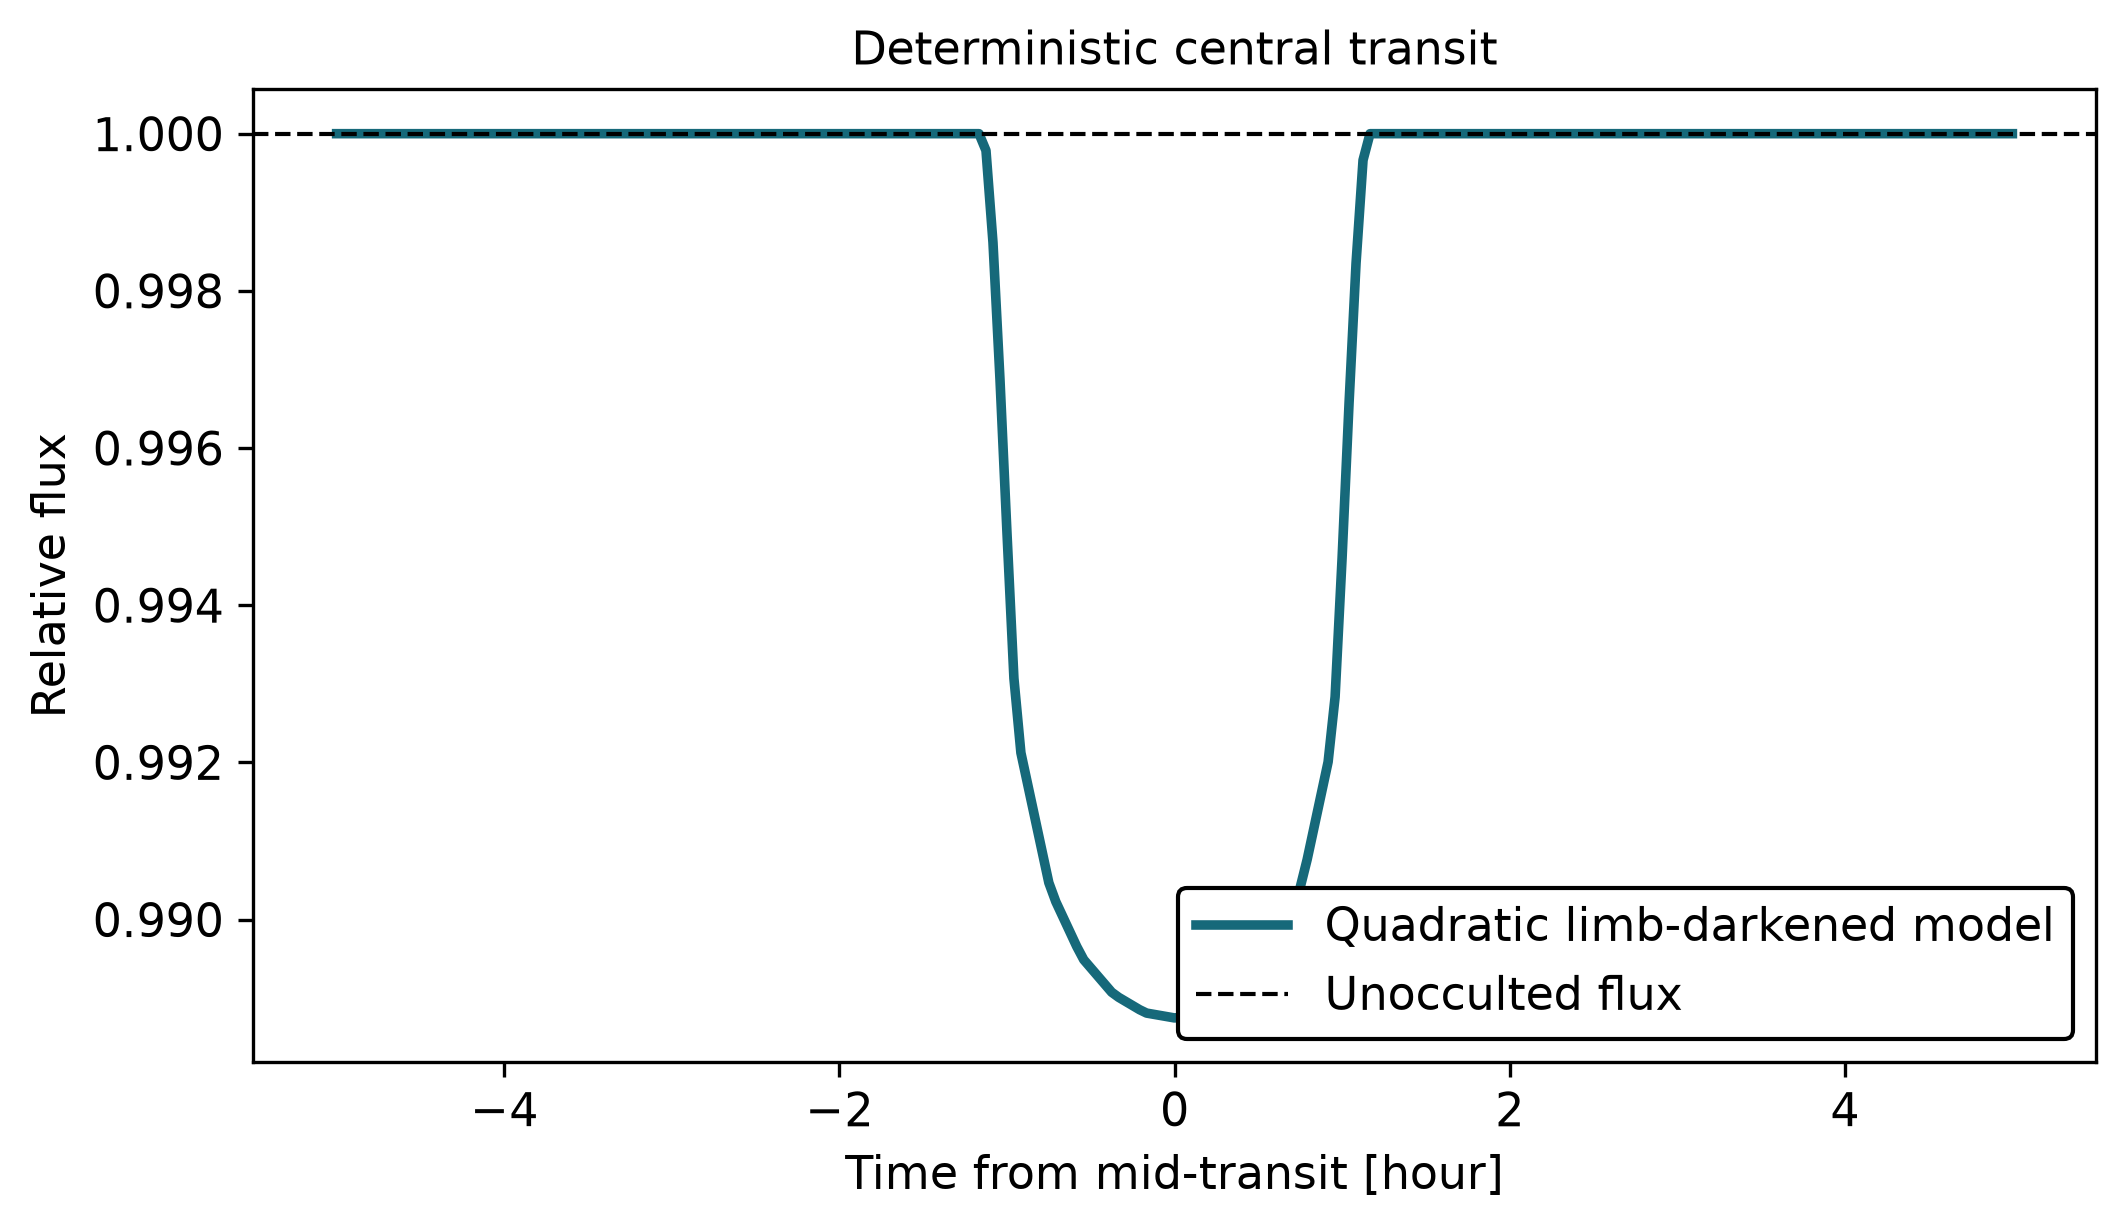

,model,minimum_relative_flux,maximum_relative_flux
0,Central transit,0.988748,1.000000
1,Emitting companion,1.000000,1.000106
2,Self-lensing,1.000000,1.000471
3,Vertical rings,0.990400,1.000000


In [3]:
time_hours = np.linspace(-5.0, 5.0, 241)  # [hour]
time_days = time_hours / 24.0  # [day]
transit_configuration = {
    "period_days": 3.0,  # [day]
    "radius_ratio": 0.1,
    "summed_radius_to_semimajor_axis": 0.1,
}
transit_flux = ephesos.evaluate_transit_model(time_days, **transit_configuration)
emitting_companion_flux = ephesos.evaluate_emitting_companion_model(
    np.linspace(0.25, 0.75, 241),  # [day]
    period_days=1.0,  # [day]
    radius_ratio=0.1,
    summed_radius_to_semimajor_axis=0.2,
    companion_brightness_ratio=0.01,
)
self_lensing_flux = ephesos.evaluate_self_lensing_model(
    time_days,
    period_days=30.0,  # [day]
    source_radius_solar=1.0,  # [solar radius]
    source_mass_solar=1.0,  # [solar mass]
    lens_mass_solar=0.6,  # [solar mass]
    impact_parameter=0.2,
    grid_size=201,
)
ringed_flux = ephesos.evaluate_projected_occultor_model(
    time_days,
    period_days=4.0,  # [day]
    equivalent_radius_ratio=0.09,
    summed_radius_to_semimajor_axis=0.12,
    occultor_type="vertical_rings",
    cosine_inclination=0.03,
    grid_size=201,
)
figure_path = output_directory / "minimal_transit.png"
ephesos.save_light_curve_figure(
    time_hours,
    transit_flux,
    figure_path,
    title="Deterministic central transit",
    time_label="Time from mid-transit [hour]",
    model_label="Quadratic limb-darkened model",
)
display(Image(filename=str(figure_path)))
pd.DataFrame(
    {
        "model": (
            "Central transit",
            "Emitting companion",
            "Self-lensing",
            "Vertical rings",
        ),
        "minimum_relative_flux": (
            transit_flux.min(),
            emitting_companion_flux.min(),
            self_lensing_flux.min(),
            ringed_flux.min(),
        ),
        "maximum_relative_flux": (
            transit_flux.max(),
            emitting_companion_flux.max(),
            self_lensing_flux.max(),
            ringed_flux.max(),
        ),
    }
)

## 5. Process Batch and Asynchronous Requests

Ephesos exposes synchronous numerical functions rather than an asynchronous service API. Batch processing is therefore expressed as deterministic array construction or ordinary Python iteration.

## 6. Handle Errors and Edge Cases

Public wrappers reject empty time arrays and unphysical orbital parameters with actionable `ValueError` messages.

In [4]:
radius_ratios = np.array((0.04, 0.07, 0.10))
batch_fluxes = np.vstack(
    [
        ephesos.evaluate_transit_model(
            time_days,
            period_days=3.0,  # [day]
            radius_ratio=radius_ratio,
            summed_radius_to_semimajor_axis=0.1,
        )
        for radius_ratio in radius_ratios
    ]
)
asynchronous_api_available = any(
    inspect.iscoroutinefunction(getattr(ephesos, name)) for name in capability_names
)

error_messages = {}
for case, invalid_time, invalid_period in (
    ("empty time", np.array([]), 3.0),
    ("nonpositive period", time_days, 0.0),
):
    try:
        ephesos.evaluate_transit_model(
            invalid_time,
            period_days=invalid_period,  # [day]
            radius_ratio=0.1,
            summed_radius_to_semimajor_axis=0.1,
        )
    except ValueError as error:
        error_messages[case] = str(error)

{
    "batch_shape": batch_fluxes.shape,
    "asynchronous_api_available": asynchronous_api_available,
    "errors": error_messages,
}

{'batch_shape': (3, 241),
 'asynchronous_api_available': False,
 'errors': {'empty time': 'time_days must be a finite one-dimensional array',
  'nonpositive period': 'period_days must be positive'}}

## 7. Visualize and Compare Results

The table preserves every model sample for inspection. The figure compares transit dimming, ring-induced dimming, and self-lensing brightening on a common parts-per-thousand scale.

Writing to visuals/capability_comparison.png...


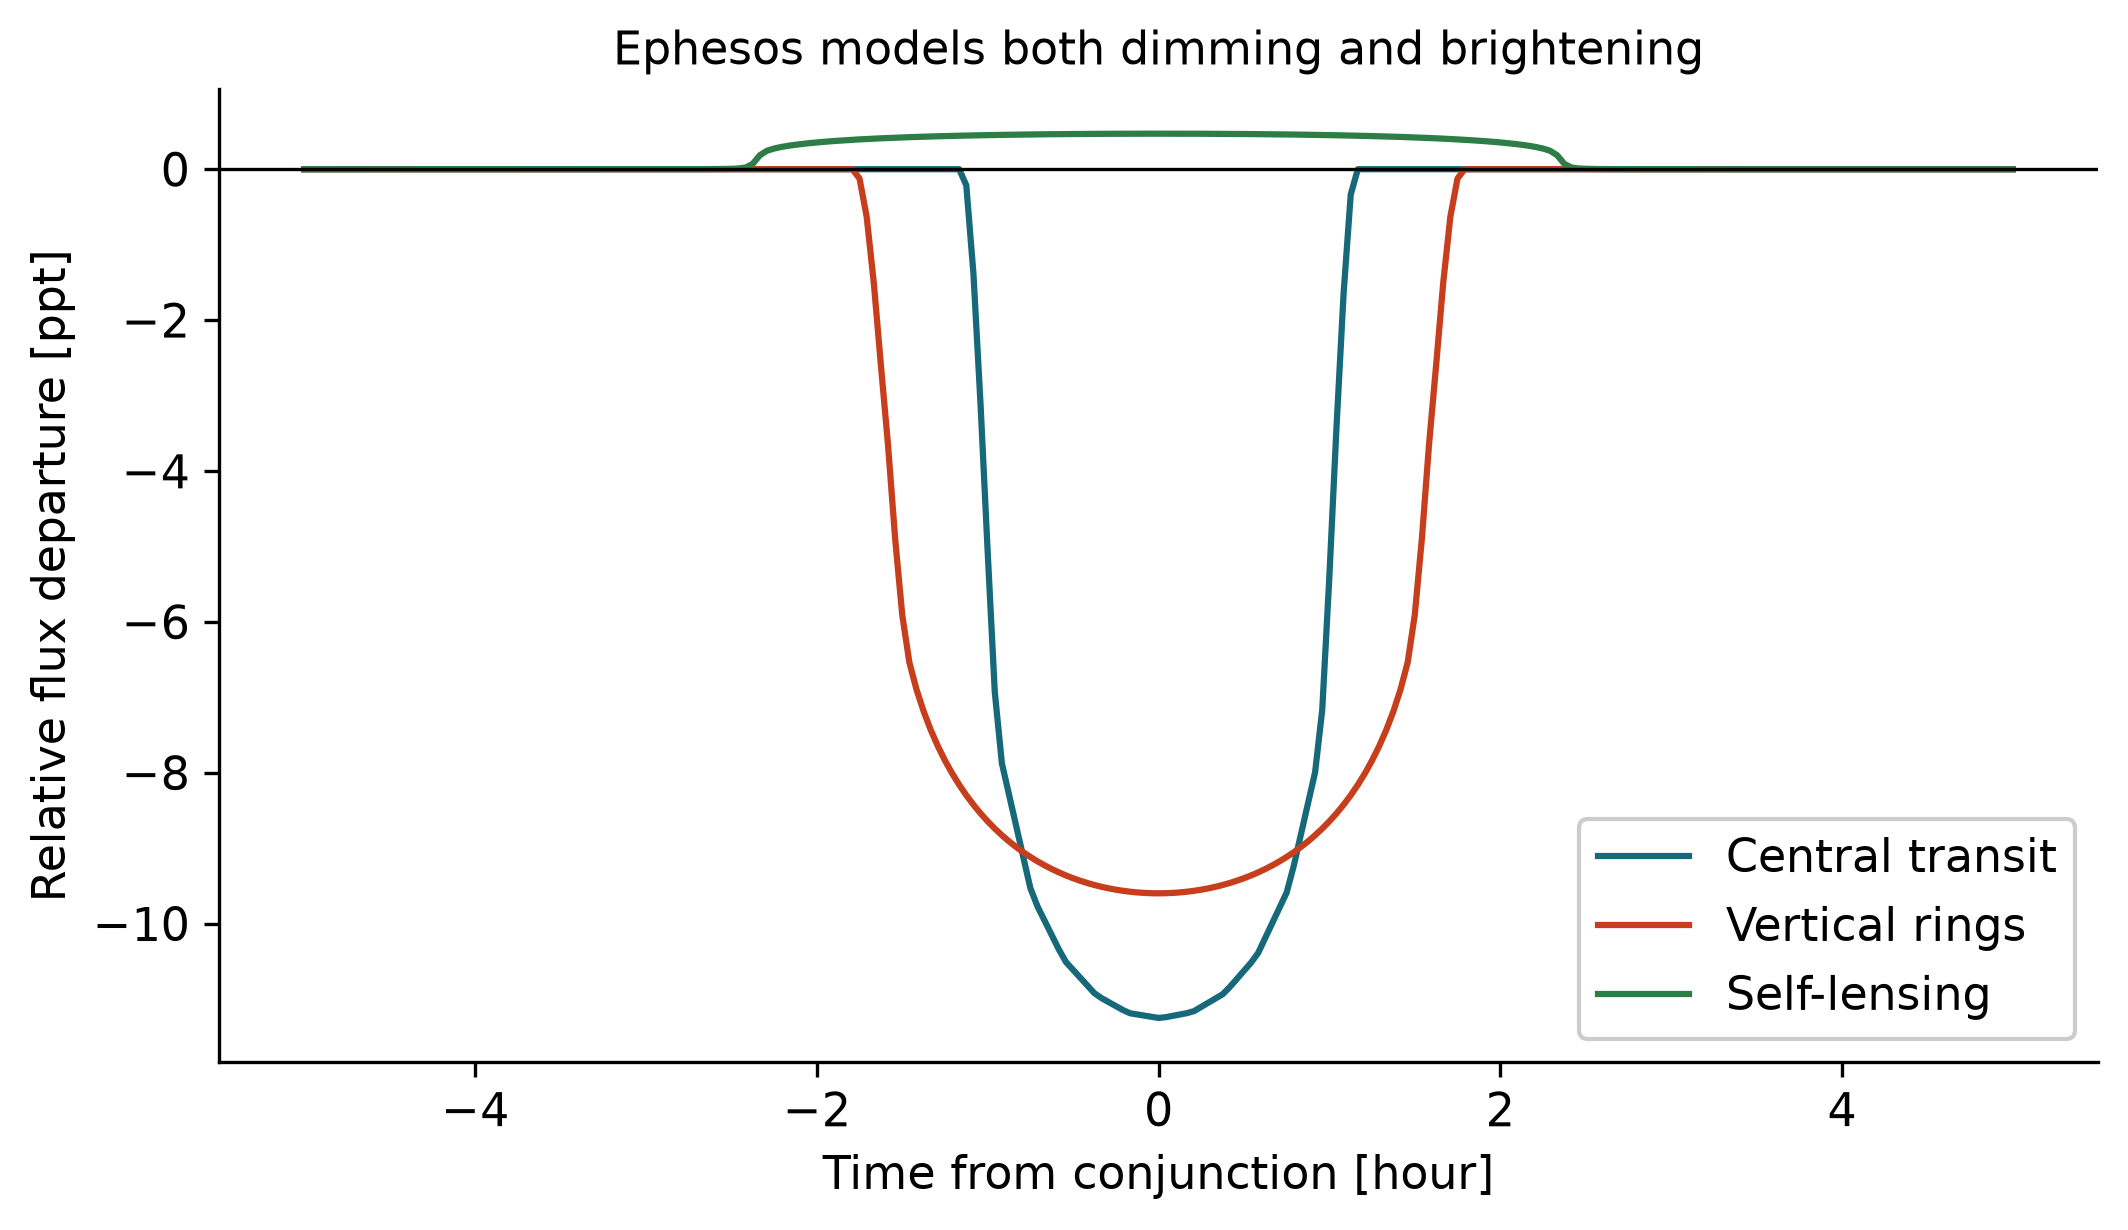

,time_hours,central_transit_ppt,vertical_rings_ppt,self_lensing_ppt
0,-5.000000,0.0,0.0,0.0
1,-4.958333,0.0,0.0,0.0
2,-4.916667,0.0,0.0,0.0
3,-4.875000,0.0,0.0,0.0
4,-4.833333,0.0,0.0,0.0


In [5]:
comparison = pd.DataFrame(
    {
        "time_hours": time_hours,
        "central_transit_ppt": 1e3 * (transit_flux - 1.0),
        "vertical_rings_ppt": 1e3 * (ringed_flux - 1.0),
        "self_lensing_ppt": 1e3 * (self_lensing_flux - 1.0),
    }
)
figure, axis = plt.subplots(figsize=(7.2, 4.2), facecolor="white")
for column, label, color in (
    ("central_transit_ppt", "Central transit", "#16697A"),
    ("vertical_rings_ppt", "Vertical rings", "#C73E1D"),
    ("self_lensing_ppt", "Self-lensing", "#2D7D46"),
):
    axis.plot(comparison["time_hours"], comparison[column], label=label, color=color)
axis.axhline(0.0, color="black", linewidth=0.8)
axis.set_xlabel("Time from conjunction [hour]", fontsize=11.0)
axis.set_ylabel("Relative flux departure [ppt]", fontsize=11.0)
axis.set_title("Ephesos models both dimming and brightening", fontsize=11.0)
axis.tick_params(labelsize=11.0)
axis.grid(False)
axis.spines[["top", "right"]].set_visible(False)
axis.legend(loc="lower right", fancybox=True, framealpha=1.0, fontsize=11.0)
figure.tight_layout()
comparison_path = output_directory / "capability_comparison.png"
narrate(f"Writing to {comparison_path}...")
figure.savefig(comparison_path, dpi=300, bbox_inches="tight")
plt.close(figure)
display(Image(filename=str(comparison_path)))
comparison.head()

## 8. Validate Examples with Tests

These assertions are lightweight enough for notebook execution and mirror pytest-compatible checks of shapes, physical direction, batch ordering, and failure behavior.

## 9. Benchmark Capability Performance

The final cell measures wall-clock time and peak traced Python memory for representative transit, self-lensing, and projected-occultor evaluations.

In [6]:
def test_capability_outputs():
    assert transit_flux.shape == self_lensing_flux.shape == ringed_flux.shape == time_hours.shape
    assert transit_flux.min() < 1.0
    assert self_lensing_flux.max() > 1.0
    assert ringed_flux.min() < 1.0
    assert np.all(np.diff(batch_fluxes.min(axis=1)) < 0.0)
    assert set(error_messages) == {"empty time", "nonpositive period"}
    assert figure_path.is_file() and comparison_path.is_file()


def benchmark(label, operation):
    tracemalloc.start()
    start_time = time.perf_counter()
    operation()
    elapsed_seconds = time.perf_counter() - start_time  # [s]
    _, peak_bytes = tracemalloc.get_traced_memory()  # [byte]
    tracemalloc.stop()
    return {
        "capability": label,
        "elapsed_milliseconds": 1e3 * elapsed_seconds,
        "peak_memory_megabytes": peak_bytes / 1e6,
    }


test_capability_outputs()
benchmark_results = pd.DataFrame(
    [
        benchmark(
            "Transit",
            lambda: ephesos.evaluate_transit_model(time_days, **transit_configuration),
        ),
        benchmark(
            "Self-lensing",
            lambda: ephesos.evaluate_self_lensing_model(
                time_days,
                period_days=30.0,  # [day]
                source_radius_solar=1.0,  # [solar radius]
                source_mass_solar=1.0,  # [solar mass]
                lens_mass_solar=0.6,  # [solar mass]
                grid_size=201,
            ),
        ),
        benchmark(
            "Projected rings",
            lambda: ephesos.evaluate_projected_occultor_model(
                time_days,
                period_days=4.0,  # [day]
                equivalent_radius_ratio=0.09,
                summed_radius_to_semimajor_axis=0.12,
                occultor_type="vertical_rings",
                grid_size=201,
            ),
        ),
    ]
)
benchmark_results

,capability,elapsed_milliseconds,peak_memory_megabytes
0,Transit,100.507584,258.384412
1,Self-lensing,4.992042,7.205771
2,Projected rings,3.077750,6.883462
